In [1]:
from experiments.dj.posterior_tables import SBVGPConfig
from experiments.dj.sysident_tables import SIConfig
from experiments.dj.result_tables import (
    SBVGPResult2,
    SIResult,
    FlowPriorResult,
    SBVGPAdaptedResult,
    FPSamplesConfig,
    FPSamples,
    MLPCondSamples2,
    AdaptPriorResult,
    LikelihoodResult,
)
from experiments.dj.dataloader_tables import DataLoaderConfig


from task_transfer.utils.insilico_stimuli import generate_gabors
from task_transfer.ml_lib.data_loading import build_dataloaders

from task_transfer.evaluation.evaluate_generative_model import (
    compute_logl,
    compute_haefner_logl_i_cond_x,
    visualize_conditional_features,
)

import torch
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

from task_transfer.sampling_models.plotting import plot_cohen_task, plot_haefner_model


from task_transfer.utils.model_utils import build_haefner_model

import experiments.orientation_discrimination.haefner_model.configs as cfg

from pathlib import Path

import pickle

from torch.utils.data import DataLoader, Dataset, ConcatDataset


import numpy as np
from task_transfer.utils.math_utils import cos2_von_mises

torch.manual_seed(42)

[2024-08-29 19:42:42,455][INFO]: Connecting sshrinivasan@134.76.19.44:3306
[2024-08-29 19:42:42,479][INFO]: Connected sshrinivasan@134.76.19.44:3306


/usr/local/lib/python3.8/dist-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: libtorch_cuda_cu.so: cannot open shared object file: No such file or directory
  warn(f"Failed to load image Python extension: {e}")


In [39]:
task1_params = cfg.haefner_model_4neuron_highdelta_task1
task2_params = cfg.haefner_model_4neuron_highdelta_task2

task1_data_model = build_haefner_model(
    p_c=task1_params["p_c"],
    c1_psi=task1_params["c1_psi"],
    c2_psi=task1_params["c2_psi"],
    kappa=task1_params["kappa"],
    g_phi=task1_params["g_phi"],
    delta=task1_params["delta"],
    lam=task1_params["lam"],
    x_phi=task1_params["x_phi"],
    obs_sigma=task1_params["obs_sigma"],
    obs_h=task1_params["obs_h"],
    obs_w=task1_params["obs_w"],
)

task2_data_model = build_haefner_model(
    p_c=task2_params["p_c"],
    c1_psi=task2_params["c1_psi"],
    c2_psi=task2_params["c2_psi"],
    kappa=task2_params["kappa"],
    g_phi=task2_params["g_phi"],
    delta=task2_params["delta"],
    lam=task2_params["lam"],
    x_phi=task2_params["x_phi"],
    obs_sigma=task2_params["obs_sigma"],
    obs_h=task2_params["obs_h"],
    obs_w=task2_params["obs_w"],
)

In [24]:
def get_gamma_mean(gamma_gensn_fn, cond):
    gamma_gensn_fn.eval()
    with torch.no_grad():
        dist = gamma_gensn_fn.trainable_distribution.distribution(cond=cond)
        return dist.base_dist.concentration / dist.base_dist.rate

In [3]:
dl1_id = "bb9bdd1ccd59e5a8c801d7f2d43e0317"
dl2_id = "5352c4a57ef18797b082283de593157b"

In [4]:
metric = "val_ll_mean"
limit = 1
download_path = "/tmp"

si_restriction1 = f"dl_id = '{dl1_id}'"
si1 = (SIResult & si_restriction1).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

sbv_restriction1 = f"dl_id = '{dl1_id}'"
sbv_restriction1_50k = sbv_restriction1 + " and n_samples = 50000"
sbv1_50k = (SBVGPResult2 & sbv_restriction1_50k).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

sbv_restriction1_30k = sbv_restriction1 + " and n_samples = 30000"
sbv1_30k = (SBVGPResult2 & sbv_restriction1_30k).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

sbv_restriction1_20k = sbv_restriction1 + " and n_samples = 20000"
sbv1_20k = (SBVGPResult2 & sbv_restriction1_20k).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

sbv_restriction1_10k = sbv_restriction1 + " and n_samples = 10000"
sbv1_10k = (SBVGPResult2 & sbv_restriction1_10k).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

si1_model = torch.load(si1["model"], map_location="cpu")
sbv1_50k_model = torch.load(sbv1_50k["model"], map_location="cpu")
sbv1_30k_model = torch.load(sbv1_30k["model"], map_location="cpu")
sbv1_20k_model = torch.load(sbv1_20k["model"], map_location="cpu")
sbv1_10k_model = torch.load(sbv1_10k["model"], map_location="cpu")

sbv1_prior = (
    FlowPriorResult
    & {
        "dl_id": sbv1_50k["dl_id"],
        "trainer_id": sbv1_50k["trainer_id"],
        "fp_id": sbv1_50k["fp_samples_id"],
    }
).fetch1(download_path=download_path)
sbv1_prior_model = torch.load(
    sbv1_prior["model"],
)

sbv1_likelihood = (
    LikelihoodResult
    & {
        "dl_id": sbv1_50k["dl_id"],
        "trainer_id": sbv1_50k["ll_trainer_id"],
        "ll_id": sbv1_50k["mlpcond_samples_id"],
    }
).fetch1(download_path=download_path)
sbv1_likelihood_model = torch.load(sbv1_likelihood["model"], map_location="cpu")

In [5]:
si_restriction2 = f"dl_id = '{dl2_id}'"

si2 = (SIResult & si_restriction2).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

sbv_restriction2 = f"alt_dl_id = '{dl2_id}'"
sbv_restriction2_50k = sbv_restriction2 + " and n_samples = 50000"
sbv2_50k = (SBVGPAdaptedResult & sbv_restriction2_50k).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

sbv_restriction2_30k = sbv_restriction2 + " and n_samples = 30000"
sbv2_30k = (SBVGPAdaptedResult & sbv_restriction2_30k).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

sbv_restriction2_20k = sbv_restriction2 + " and n_samples = 20000"
sbv2_20k = (SBVGPAdaptedResult & sbv_restriction2_20k).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

sbv_restriction2_10k = sbv_restriction2 + " and n_samples = 10000"
sbv2_10k = (SBVGPAdaptedResult & sbv_restriction2_10k).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

si2_model = torch.load(si2["model"], map_location="cpu")
sbv2_50k_model = torch.load(sbv2_50k["model"], map_location="cpu")
sbv2_30k_model = torch.load(sbv2_30k["model"], map_location="cpu")
sbv2_20k_model = torch.load(sbv2_20k["model"], map_location="cpu")
sbv2_10k_model = torch.load(sbv2_10k["model"], map_location="cpu")

sbv2_gen = (
    AdaptPriorResult
    & {
        "prior_fp_id": sbv2_50k["prior_fp_id"],
        "prior_trainer_id": sbv2_50k["prior_trainer_id"],
        "dl_id": sbv2_50k["alt_dl_id"],
        "seed": sbv2_50k["data_seed"],
    }
).fetch1(download_path=download_path)
sbv2_gen_model = torch.load(sbv2_gen["model"], map_location="cpu")
sbv2_prior_model = sbv2_gen_model.prior
sbv2_likelihood_model = sbv2_gen_model.conditional

In [6]:
dataloader_config1 = {
    "data_fname": "/src/project/data/synthetic/haefner_2afc/haefner_model_4neuron_highdelta_task1_dataset.pkl",
    "train_prop": 0.7,
    "val_prop": 0.2,
    "batch_size": 128,
}
train_loader1, val_loader1, test_loader1 = build_dataloaders(
    data_fname=dataloader_config1["data_fname"],
    train_prop=dataloader_config1["train_prop"],
    val_prop=dataloader_config1["val_prop"],
    batch_size=dataloader_config1["batch_size"],
)

dataloader_config2 = {
    "data_fname": "/src/project/data/synthetic/haefner_2afc/haefner_model_4neuron_highdelta_task2_dataset.pkl",
    "train_prop": 0.7,
    "val_prop": 0.2,
    "batch_size": 128,
}
train_loader2, val_loader2, test_loader2 = build_dataloaders(
    data_fname=dataloader_config2["data_fname"],
    train_prop=dataloader_config2["train_prop"],
    val_prop=dataloader_config2["val_prop"],
    batch_size=dataloader_config2["batch_size"],
)

In [7]:
class TaggedDataset(Dataset):
    def __init__(self, dataset, source_id):
        self.dataset = dataset
        self.source_id = source_id

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        data, label = self.dataset[idx]
        return data, label, self.source_id


# Tag datasets with their respective source ids (1 and 2)
tagged_dataset1 = TaggedDataset(test_loader1.dataset, source_id=1)
tagged_dataset2 = TaggedDataset(test_loader2.dataset, source_id=2)

# Combine the two tagged datasets
combined_dataset = ConcatDataset([tagged_dataset1, tagged_dataset2])

# Create a new DataLoader with shuffling
combined_dataloader = DataLoader(combined_dataset, batch_size=144, shuffle=True)

In [8]:
responses, images, ids = next(iter(combined_dataloader))

In [9]:
images.shape

torch.Size([144, 144])

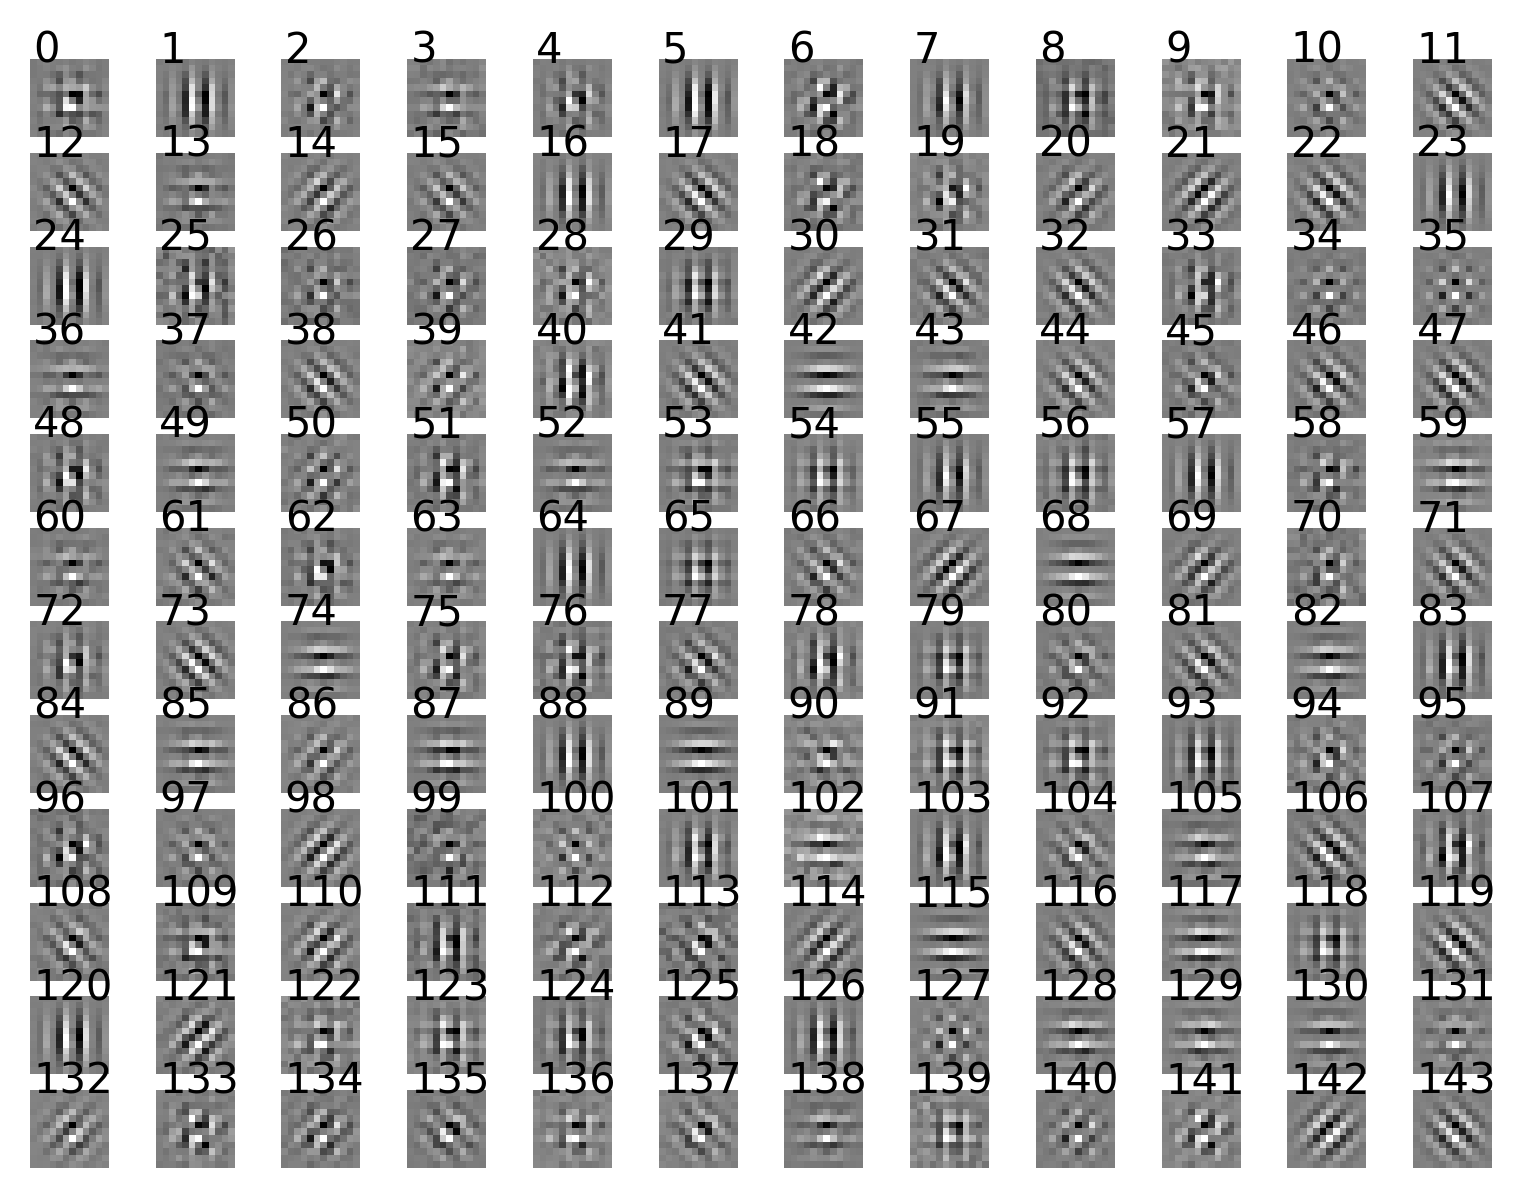

In [10]:
fig, axs = plt.subplots(12, 12, dpi=300)
for i, ax in enumerate(axs.flatten()):
    ax.imshow(images[i].numpy().reshape(12, 12), cmap="gray")
    ax.text(0, 0, i)
    ax.axis("off")
    

In [11]:
id_0 = [1, 5, 16, 23, 24]
id_45 = [11, 12, 15, 17, 22]
id_90 = [42, 43, 59, 68, 74]
id_135 = [14, 21, 30, 67, 98]

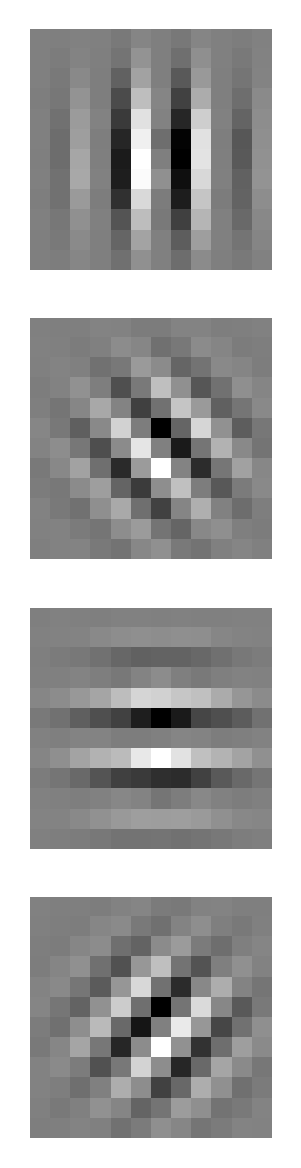

In [96]:
avg_0 = images[id_0].mean(dim=0)
avg_45 = images[id_45].mean(dim=0)
avg_90 = images[id_90].mean(dim=0)
avg_135 = images[id_135].mean(dim=0)
fig, axs = plt.subplots(4, 1, dpi=300)
axs[0].imshow(avg_0.numpy().reshape(12, 12), cmap="gray")
# axs[0].set_title("0")
axs[0].axis("off")
axs[1].imshow(avg_45.numpy().reshape(12, 12), cmap="gray")
# axs[1].set_title("45")
axs[1].axis("off")
axs[2].imshow(avg_90.numpy().reshape(12, 12), cmap="gray")
# axs[2].set_title("90")
axs[2].axis("off")
axs[3].imshow(avg_135.numpy().reshape(12, 12), cmap="gray")
# axs[3].set_title("135")
axs[3].axis("off")

fig.savefig("posterior_means_stimuli.pdf", bbox_inches="tight")

In [45]:
sbv1_avg_0_means = get_gamma_mean(sbv1_50k_model, avg_0)
sbv2_avg_0_means = get_gamma_mean(sbv2_50k_model, avg_0)

sbv1_avg_45_means = get_gamma_mean(sbv1_50k_model, avg_45)
sbv2_avg_45_means = get_gamma_mean(sbv2_50k_model, avg_45)

sbv1_avg_90_means = get_gamma_mean(sbv1_50k_model, avg_90)
sbv2_avg_90_means = get_gamma_mean(sbv2_50k_model, avg_90)

sbv1_avg_135_means = get_gamma_mean(sbv1_50k_model, avg_135)
sbv2_avg_135_means = get_gamma_mean(sbv2_50k_model, avg_135)

In [87]:
si1_avg_0_means = get_gamma_mean(si1_model, avg_0)
si2_avg_0_means = get_gamma_mean(si2_model, avg_0)

si1_avg_45_means = get_gamma_mean(si1_model, avg_45)
si2_avg_45_means = get_gamma_mean(si2_model, avg_45)

si1_avg_90_means = get_gamma_mean(si1_model, avg_90)
si2_avg_90_means = get_gamma_mean(si2_model, avg_90)

si1_avg_135_means = get_gamma_mean(si1_model, avg_135)
si2_avg_135_means = get_gamma_mean(si2_model, avg_135)

In [56]:
max(sbv1_avg_0_means.max(), sbv2_avg_0_means.max())

tensor(12.3739)

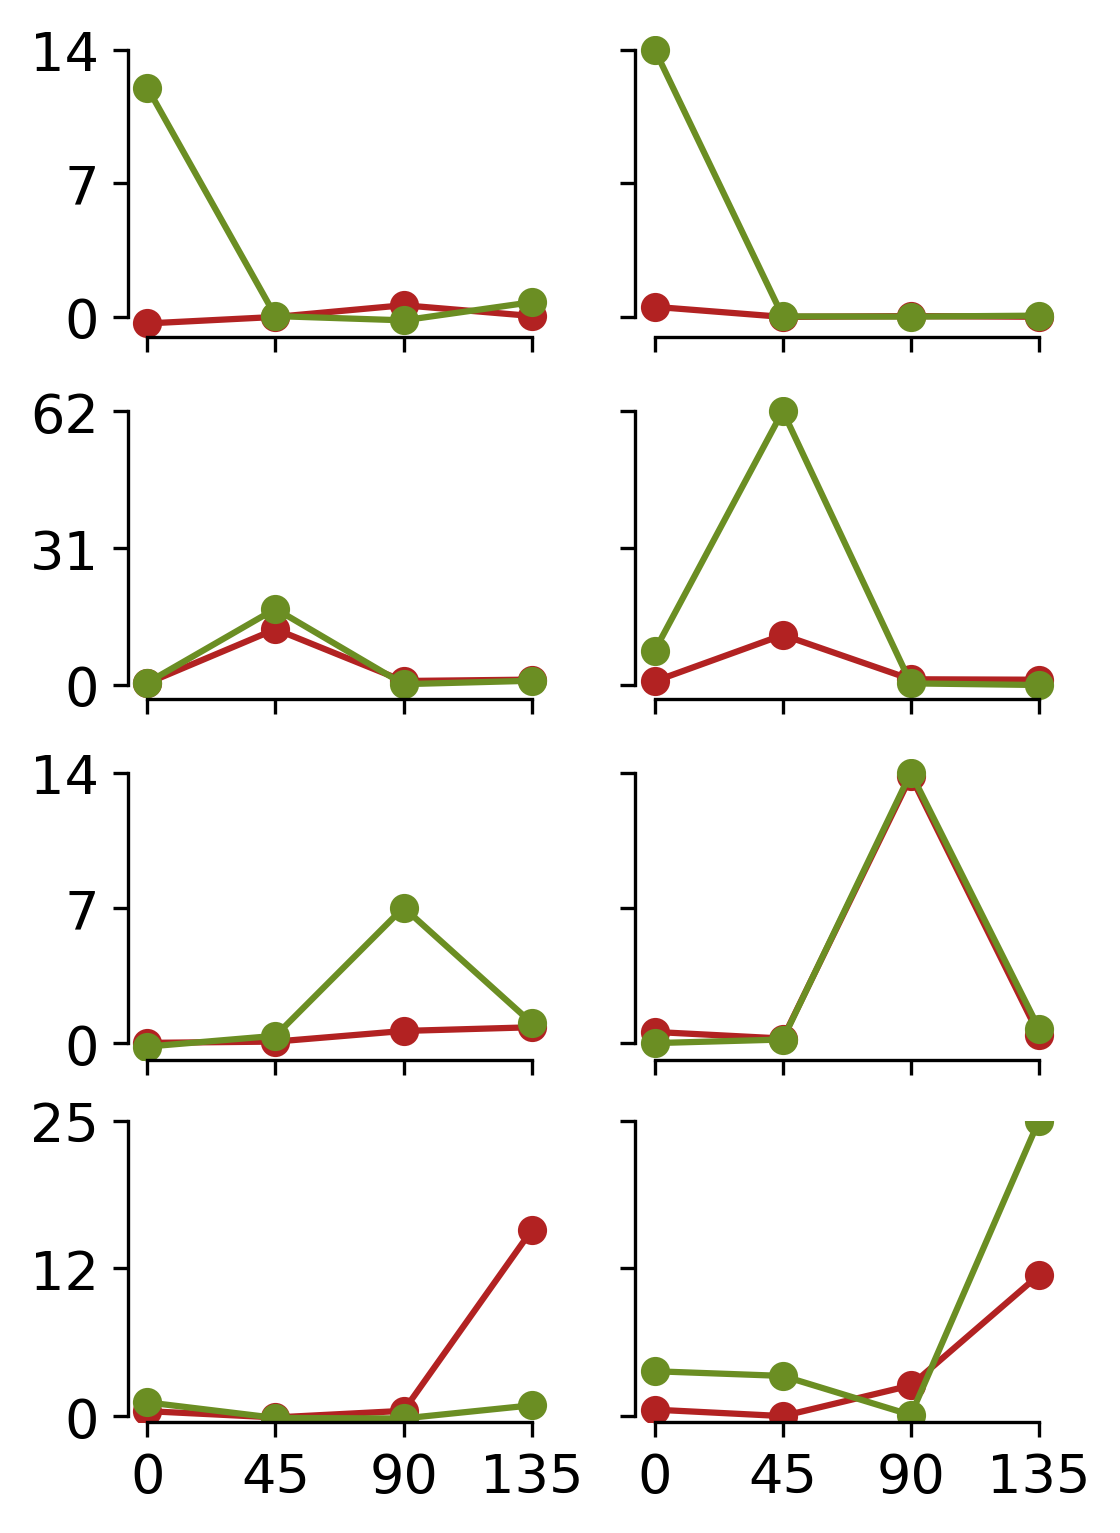

In [103]:
fig, axs = plt.subplots(4, 2, sharex="col", sharey="row", dpi=300, figsize=(4, 6))
linestyle = "-"
sbv1_color = "firebrick"
sbv2_color = "olivedrab"
si1_color = "firebrick"
si2_color = "olivedrab"
marker = "o"
x = [0, 1, 2, 3]
axs[0][0].plot(x, sbv1_avg_0_means, linestyle=linestyle, marker=marker, color=sbv1_color)
axs[0][0].plot(x, sbv2_avg_0_means, linestyle=linestyle, marker=marker, color=sbv2_color)
min_y = min(sbv1_avg_0_means.min(), sbv2_avg_0_means.min())
max_y = max(sbv1_avg_0_means.max(), sbv2_avg_0_means.max())
axs[0][0].set_yticks(np.linspace(min_y, max_y, 3))
axs[0][0].set_yticklabels([f"{int(y)}" for y in np.linspace(min_y, max_y, 3)])

axs[1][0].plot(x, sbv1_avg_45_means, linestyle=linestyle, marker=marker, color=sbv1_color)
axs[1][0].plot(x, sbv2_avg_45_means, linestyle=linestyle, marker=marker, color=sbv2_color)
min_y = min(sbv1_avg_45_means.min(), sbv2_avg_45_means.min())
max_y = max(sbv1_avg_45_means.max(), sbv2_avg_45_means.max())
axs[1][0].set_yticks(np.linspace(min_y, max_y, 3))
axs[1][0].set_yticklabels([f"{int(y)}" for y in np.linspace(min_y, max_y, 3)])

axs[2][0].plot(x, sbv1_avg_90_means, linestyle=linestyle, marker=marker, color=sbv1_color)
axs[2][0].plot(x, sbv2_avg_90_means, linestyle=linestyle, marker=marker, color=sbv2_color)
min_y = min(sbv1_avg_90_means.min(), sbv2_avg_90_means.min())
max_y = max(sbv1_avg_90_means.max(), sbv2_avg_90_means.max())
axs[2][0].set_yticks(np.linspace(min_y, max_y, 3))
axs[2][0].set_yticklabels([f"{int(y)}" for y in np.linspace(min_y, max_y, 3)])

axs[3][0].plot(x, sbv1_avg_135_means, linestyle=linestyle, marker=marker, color=sbv1_color)
axs[3][0].plot(x, sbv2_avg_135_means, linestyle=linestyle, marker=marker, color=sbv2_color)
axs[3][0].set_ylim(0, max(sbv1_avg_135_means.max(), sbv2_avg_135_means.max()))
min_y = min(sbv1_avg_135_means.min(), sbv2_avg_135_means.min())
max_y = max(sbv1_avg_135_means.max(), sbv2_avg_135_means.max())
axs[3][0].set_yticks(np.linspace(min_y, max_y, 3))
axs[3][0].set_yticklabels([f"{int(y)}" for y in np.linspace(min_y, max_y, 3)])

# for ax in axs.ravel():
#     # ax.set_xticks(x)
#     # ax.set_ylabel("Mean rate")
#     sns.despine(ax=ax, trim=True)
# ax.set_xticklabels(["0", "45", "90", "135"])
# ax.set_xlabel("Orientation preference, $\psi^x$")

axs[0][1].plot(
    x, si1_avg_0_means, linestyle=linestyle, marker=marker, color=si1_color
)
axs[0][1].plot(
    x, si2_avg_0_means, linestyle=linestyle, marker=marker, color=si2_color
)
min_y = min(si1_avg_0_means.min(), si2_avg_0_means.min())
max_y = max(si1_avg_0_means.max(), si2_avg_0_means.max())
axs[0][1].set_yticks(np.linspace(min_y, max_y, 3))
axs[0][1].set_yticklabels([f"{int(y)}" for y in np.linspace(min_y, max_y, 3)])

axs[1][1].plot(
    x, si1_avg_45_means, linestyle=linestyle, marker=marker, color=si1_color
)
axs[1][1].plot(
    x, si2_avg_45_means, linestyle=linestyle, marker=marker, color=si2_color
)
min_y = min(si1_avg_45_means.min(), si2_avg_45_means.min())
max_y = max(si1_avg_45_means.max(), si2_avg_45_means.max())
axs[1][1].set_yticks(np.linspace(min_y, max_y, 3))
axs[1][1].set_yticklabels([f"{int(y)}" for y in np.linspace(min_y, max_y, 3)])

axs[2][1].plot(
    x, si1_avg_90_means, linestyle=linestyle, marker=marker, color=si1_color
)
axs[2][1].plot(
    x, si2_avg_90_means, linestyle=linestyle, marker=marker, color=si2_color
)
min_y = min(si1_avg_90_means.min(), si2_avg_90_means.min())
max_y = max(si1_avg_90_means.max(), si2_avg_90_means.max())
axs[2][1].set_yticks(np.linspace(min_y, max_y, 3))
axs[2][1].set_yticklabels([f"{int(y)}" for y in np.linspace(min_y, max_y, 3)])

axs[3][1].plot(
    x, si1_avg_135_means, linestyle=linestyle, marker=marker, color=si1_color
)
axs[3][1].plot(
    x, si2_avg_135_means, linestyle=linestyle, marker=marker, color=si2_color
)
axs[3][1].set_ylim(0, max(si1_avg_135_means.max(), si2_avg_135_means.max()))
min_y = min(si1_avg_135_means.min(), si2_avg_135_means.min())
max_y = max(si1_avg_135_means.max(), si2_avg_135_means.max())
axs[3][1].set_yticks(np.linspace(min_y, max_y, 3))
axs[3][1].set_yticklabels([f"{int(y)}" for y in np.linspace(min_y, max_y, 3)])

for ax in axs.ravel():
    ax.set_xticks(x)
    # ax.set_ylabel("Mean rate")
    ax.tick_params(axis="both", which="major", labelsize=13)
    sns.despine(ax=ax, trim=True)
axs[-1][0].set_xticklabels(["0", "45", "90", "135"])
axs[-1][1].set_xticklabels(["0", "45", "90", "135"])
fig.savefig("posterior_means.pdf", bbox_inches="tight")